# Pyomo Übung 1.b

### Optimierung im landwirtschaftlichen Betrieb über mehrere Perioden

Die Aufgabenstellung aus Pyomo Übung 1 bleibt bestehen: <br>
Eine Landwirtin hat eine Ackerfläche von 1 Hektar zur Verfügung. Auf dieser Fläche sollen Energiepflanzen angebaut werden. Die Landwirtin will Mais für die Biomethan-Herstellung und Zuckerrüben für die Biokraftstoff-Herstellung anbauen, wobei sich nur 6.000 m2 der Gesamtfläche für den Anbau von Zuckerrüben eignet.
Die Bestellung eines Hektars Mais kostet 1.500 €. Die eines Hektars Zuckerrüben 2.000 €.
Durch den Biomethan- bzw. Bioethanolpreis, der Effizienz der Vergärung und der Energiedichte der Pflanzen kann man die Erlöse auf 0,25 € je m2 Mais und 0,40 € je m2 Zuckerrüben datieren.
Zum aktuellen Zeitpunkt steht der Landwirtin ein Kapital von 1.650 € zur Verfügung.


Nun sollen die zwei darauffolgenden Jahre mit berücksichtigt werden. Im zweiten Jahr fallen Kosten von 1710 € für die Reparatur des Traktors an. Dadurch reduzieren sich jedoch auch die Kosten für das Bestellen der Felder je um 300 €. Darüber hinaus fallen die Preise für Bioethanol und somit der Erlös von Zuckerrüben auf 0,30 € je m2.

Importieren Sie die notwendigen Bibliotheken

In [26]:
import pyomo.environ as pyo
import pandas as pd

Erstellen Sie nun das Modell und benennen Sie dieses. Definieren Sie ein Set, welches die 3 Jahre abbildet

In [16]:
model = pyo.ConcreteModel(name = 'Übung 1b')
model.T = pyo.Set(initialize = [1,2,3])

Parametrisieren Sie nun Ihr Modell neu. Beachten Sie, dass manche Parameter nun abhängig von der jeweiligen Periode sind

In [17]:
model.Feld_Groesse = pyo.Param(initialize = 10000, 
                               name='Größe des Felds in m^2')
model.Max_Zuckerrueben = pyo.Param(initialize = 6000, 
                                   name='Maximale Fläche für Zuckerrüben in m^2')
model.Kosten_Mais = pyo.Param(model.T, initialize = {1:0.15, 2:0.12, 3:0.12},
                              name = ' Kosten für Mais in €/m^2')
model.Kosten_Zuckerrueben = pyo.Param(model.T, initialize = {1:0.20, 2:0.17, 3:0.17}, 
                                        name='Kosten für Zuckerrüben in €/m^2')
model.Erloes_Zuckerrueben = pyo.Param(model.T, initialize = {1:0.40, 2:0.30, 3:0.30}, 
                                        name='Erlös Zuckerrueben in €/m^2')
model.Erloes_Mais = pyo.Param(initialize = 0.25, name='Erlös Mais in €/m^2')
model.Startkapital = pyo.Param(initialize = 1650, name='Kapital in €')
model.Reperaturkosten = pyo.Param(model.T, initialize = {1:0, 2:1710, 3:0}, 
                                  name='Reperaturkosten in €')

In [18]:
model.A_Mais = pyo.Var(model.T, within=pyo.NonNegativeReals, 
                       doc='Fläche Mais in m2') 
model.A_Zuckerrueben = pyo.Var(model.T, within=pyo.NonNegativeReals, 
                               doc='Fläche Zuckerrüben in m2')
model.Kapital = pyo.Var(model.T, within=pyo.NonNegativeReals, 
                        doc='Kapital der Landwirtin')

Erstellen Sie nun die Zielfunktion

In [19]:
def zielfunktion(model):
    return sum(model.A_Mais[t] * (model.Erloes_Mais - model.Kosten_Mais[t]) + 
               model.A_Zuckerrueben[t] * (model.Erloes_Zuckerrueben[t] - model.Kosten_Zuckerrueben[t])
               for t in model.T)
model.obj = pyo.Objective(rule = zielfunktion, sense = pyo.maximize)

Erstellen Sie neue Nebenbedingungen. Achten Sie darauf, dass diese nun für die jeweiligen Perioden gelten

In [20]:
def rule_feldgroesse(model,t):
    return model.A_Mais[t] + model.A_Zuckerrueben[t] <= model.Feld_Groesse
model.con_feldgroesse = pyo.Constraint(model.T, rule = rule_feldgroesse,
                                       name='Feldgröße')
def rule_zuckergroesse(model,t):
    return model.A_Zuckerrueben[t] <= model.Max_Zuckerrueben
    
model.con_zuckergroesse = pyo.Constraint(model.T, rule = rule_zuckergroesse, 
                                         name='Zuckergröße')

def rule_invest(model,t):
    return model.A_Mais[t] * model.Kosten_Mais[t] + model.A_Zuckerrueben[t] * model.Kosten_Zuckerrueben[t] <= model.Kapital[t]
model.con_invest = pyo.Constraint(model.T, rule = rule_invest, 
                                  name='Maximaler Invest')

def rule_kapital(model, t):
    if t == 1:
        return model.Kapital[t] == model.Startkapital
    else:
        return model.Kapital[t] == model.A_Mais[t-1]*(model.Erloes_Mais - model.Kosten_Mais[t-1]) + model.A_Zuckerrueben[t-1] * (model.Erloes_Zuckerrueben[t-1] - model.Kosten_Zuckerrueben[t-1]) + model.Kapital[t-1] - model.Reperaturkosten[t]

model.con_kapital = pyo.Constraint(model.T, rule=rule_kapital, 
                                   name = 'Zur Verfügung stehendes Kapital in €')


Lösen Sie das Modell

In [21]:
solver = pyo.SolverFactory('cbc')
solver.solve(model)

{'Problem': [{'Name': 'unknown', 'Lower bound': 4100.0, 'Upper bound': 4100.0, 'Number of objectives': 1, 'Number of constraints': 12, 'Number of variables': 9, 'Number of nonzeros': 6, 'Sense': 'maximize'}], 'Solver': [{'Status': 'ok', 'User time': -1.0, 'System time': 0.02, 'Wallclock time': 0.01, 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': None, 'Number of created subproblems': None}, 'Black box': {'Number of iterations': 5}}, 'Error rc': 0, 'Time': 0.021961450576782227}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

Lassen Sie sich die Flächen für Mais und Zuckerrüben, sowie den Gewinn nach Jahr 3 ausgeben

In [25]:
print('Mais', round(model.A_Mais[3].value, 2), 'm^2')
print('Zuckerrüben', round(model.A_Zuckerrueben[3].value, 2), 'm^2')
print("Gewinn:", round(model.obj(), 2), '€') # Berücksichtigt kein Anfangskapital und keine Reperaturkosten

Mais 4000.0 m^2
Zuckerrüben 6000.0 m^2
Gewinn: 4100.0 €


Erstellen Sie ein Lösungs-DataFrame und geben Sie sich den Verlauf für die Flächen von Mais und Zuckerrüben, sowie das Kapital vor jedem Investment und den Erlös jedes Jahres grafisch aus

In [29]:
# Vorbereiteter Datenrahmen
ergebnisse = []

# Schleife über die Zeitperioden und extrahiere die Werte
for i in model.T:
    ergebnisse.append({
        'A_Mais': pyo.value(model.A_Mais[i]),
        'A_Zuckerrüben': pyo.value(model.A_Zuckerrueben[i]),
        'Kapital': pyo.value(model.Kapital[i]),
        'Gewinn': pyo.value(model.A_Mais[i]  * (model.Erloes_Mais - model.Kosten_Mais[i]) + model.A_Zuckerrueben[i] * (model.Erloes_Zuckerrueben[i] - model.Kosten_Zuckerrueben[i]))
    })

# Erstelle ein Pandas DataFrame
df = pd.DataFrame(ergebnisse)

In [30]:
df

,A_Mais,A_Zuckerrüben,Kapital,Gewinn
0,3000.0,6000.0,1650.0,1500.0
1,5200.0,4800.0,1440.0,1300.0
2,4000.0,6000.0,2740.0,1300.0


<Axes: >

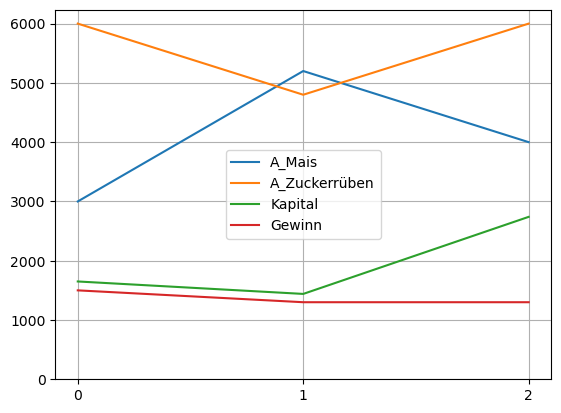

In [31]:
df.plot(grid=True, ylim=0, xticks = [0,1,2])